# 02 — Time-Domain Analysis
**Phase 1 · Multi-fault Diagnosis of Rotating Machinery**

Goals:
- Extract time-domain features per accelerometer channel (RMS, kurtosis, crest factor, etc.)
- Compare feature distributions across fault conditions
- Identify the most discriminative time-domain features

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from scipy.fft import rfft, rfftfreq
import seaborn as sns

In [44]:
DATA_ROOT = Path("../../data/raw")
SAMPLING_RATE = 50_000  # Hz

CHANNEL_NAMES = [
    "tachometer",
    "underhang_axial", "underhang_radial", "underhang_tangential",
    "overhang_axial",  "overhang_radial",  "overhang_tangential",
    "microphone",
]

ACCEL_CHANNELS = [
    "underhang_axial", "underhang_radial", "underhang_tangential",
    "overhang_axial",  "overhang_radial",  "overhang_tangential",
]

In [45]:
# TODO: import or redefine time_domain_features() and estimate_rotation_frequency()
# Migrate from eda-mafaulda.ipynb once stabilised

In [46]:
# TODO: run feature extraction across all files and store in a DataFrame

In [47]:
# TODO: boxplots / violin plots of each feature grouped by fault class

In [48]:
def estimate_rotation_frequency(tacho: np.ndarray, fs: int = SAMPLING_RATE) -> float:
    tacho = np.asarray(tacho, dtype=np.float64) - tacho.mean()
    mag   = np.abs(rfft(tacho * np.hanning(len(tacho))))
    freqs = rfftfreq(len(tacho), d=1.0 / fs)
    valid = (freqs >= 5.0) & (freqs <= 100.0)
    return float(freqs[valid][np.argmax(mag[valid])]) if valid.any() else 0.0


def time_domain_features(x: np.ndarray) -> dict:
    x        = np.asarray(x, dtype=np.float64)
    abs_x    = np.abs(x)
    rms      = float(np.sqrt(np.mean(x ** 2)))
    peak     = float(abs_x.max())
    mean_abs = float(abs_x.mean())
    sqrt_mean_sq = float(np.mean(np.sqrt(abs_x)) ** 2)

    return {
        "mean":               float(x.mean()),
        "std":                float(x.std()),
        "rms":                rms,
        "peak":               peak,
        "peak_to_peak":       float(x.max() - x.min()),
        "crest_factor":       peak / rms          if rms          > 0 else 0.0,
        "shape_factor":       rms  / mean_abs     if mean_abs     > 0 else 0.0,
        "impulse_factor":     peak / mean_abs     if mean_abs     > 0 else 0.0,
        "margin_factor":      peak / sqrt_mean_sq if sqrt_mean_sq > 0 else 0.0,
        "skewness":           float(stats.skew(x)),
        "kurtosis":           float(stats.kurtosis(x) + 3),
        "zero_crossing_rate": float(np.sum(np.diff(np.signbit(x))) / (len(x) / SAMPLING_RATE)),
    }


In [49]:
NORMAL_DIR = Path("/kaggle/input/datasets/vuxuancu/mafaulda-full/mafaulda/normal")

csv_files = sorted(NORMAL_DIR.glob("*.csv"))
print(f"Found {len(csv_files)} files in normal/")

records = []
for csv_path in csv_files:
    df = pd.read_csv(csv_path, header=None, names=CHANNEL_NAMES)
    f_r = estimate_rotation_frequency(df["tachometer"].values)

    for ch in ACCEL_CHANNELS:
        feats = time_domain_features(df[ch].values)
        records.append({
            "file":             csv_path.name,
            "fault_type":       "normal",
            "rotation_freq_hz": f_r,
            "channel":          ch,
            **feats,
        })

df_normal = pd.DataFrame(records)
print(f"{df_normal.shape[0]} rows  ({len(csv_files)} files × {len(ACCEL_CHANNELS)} channels)")
df_normal.head(12)


Found 49 files in normal/
294 rows  (49 files × 6 channels)


,file,fault_type,rotation_freq_hz,channel,mean,std,rms,peak,peak_to_peak,crest_factor,shape_factor,impulse_factor,margin_factor,skewness,kurtosis,zero_crossing_rate
0,12.288.csv,normal,24.2,underhang_axial,-0.002661,0.979174,0.979178,3.142900,4.671300,3.209734,1.149975,3.691112,4.124692,-0.296534,1.934268,41169.6
1,12.288.csv,normal,24.2,underhang_radial,-0.000632,0.307370,0.307371,1.709000,2.333310,5.560063,1.160979,6.455118,7.227169,-0.391702,2.274055,40753.6
2,12.288.csv,normal,24.2,underhang_tangential,0.000324,0.044809,0.044810,0.188460,0.361790,4.205777,1.221301,5.136521,5.963075,-0.218167,2.622561,30088.0
3,12.288.csv,normal,24.2,overhang_axial,0.031088,0.668105,0.668827,2.280100,4.256400,3.409101,1.227602,4.185018,4.883290,0.163729,2.612859,1727.8
4,12.288.csv,normal,24.2,overhang_radial,0.003156,0.030200,0.030364,0.085668,0.168620,2.821329,1.192259,3.363755,3.852310,-0.093602,2.232541,1963.2
5,12.288.csv,normal,24.2,overhang_tangential,0.004970,0.197512,0.197575,0.790590,1.446060,4.001468,1.236777,4.948926,5.793056,-0.051334,2.749019,5411.0
6,13.1072.csv,normal,12.8,underhang_axial,0.016244,1.245481,1.245586,4.435200,6.415800,3.560732,1.156582,4.118280,4.621159,-0.360693,2.015247,39757.4
7,13.1072.csv,normal,12.8,underhang_radial,-0.000479,0.309476,0.309476,1.814800,2.416860,5.864101,1.163069,6.820354,7.641004,-0.401269,2.339577,40859.0
8,13.1072.csv,normal,12.8,underhang_tangential,0.000400,0.046526,0.046528,0.205970,0.386350,4.426799,1.226624,5.430018,6.319608,-0.203251,2.692272,28922.6
9,13.1072.csv,normal,12.8,overhang_axial,0.014122,0.893673,0.893785,2.949900,5.418400,3.300459,1.205236,3.977834,4.579167,0.180063,2.402837,1051.6


In [50]:
FEATURE_COLS = [
    "mean", "std", "rms", "peak", "peak_to_peak",
    "crest_factor", "shape_factor", "impulse_factor",
    "margin_factor", "skewness", "kurtosis", "zero_crossing_rate",
]

df_normal.groupby("channel")[FEATURE_COLS].agg(["mean", "std"]).round(4)


mean             std             rms            peak  \
                        mean     std    mean     std    mean     std    mean   
channel                                                                        
overhang_axial        0.0148  0.0379  0.5731  0.2489  0.5744  0.2491  2.1124   
overhang_radial       0.0030  0.0012  0.0334  0.0097  0.0336  0.0097  0.1187   
overhang_tangential   0.0188  0.0443  0.3875  0.1386  0.3901  0.1393  1.6446   
underhang_axial       0.0079  0.0089  0.8291  0.2051  0.8292  0.2051  3.4964   
underhang_radial     -0.0005  0.0002  0.4094  0.0823  0.4094  0.0823  2.2322   
underhang_tangential  0.0004  0.0001  0.1633  0.0851  0.1633  0.0851  0.9448   

                             peak_to_peak          ... impulse_factor          \
                         std         mean     std  ...           mean     std   
channel                                            ...                          
overhang_axial        0.7372       3.9380  1.4427  ...         4.7601  0.6155   
overhang_radial       0.0576       0.2154  0.0955  ...         4.1217  1.1830   
overhang_tangential   0.5521       3.0741  1.0076  ...         5.3256  0.8407   
underhang_axial       0.5045       5.5513  0.4702  ...         5.2550  0.9466   
underhang_radial      0.6259       3.8817  1.2980  ...         6.6193  0.8941   
underhang_tangential  0.5614       1.7996  1.0585  ...         6.9741  1.1763   

                     margin_factor         skewness         kurtosis          \
                              mean     std     mean     std     mean     std   
channel                                                                        
overhang_axial              5.5875  0.7570  -0.0902  0.2070   2.8533  0.2736   
overhang_radial             4.7360  1.3895  -0.1117  0.0816   2.3296  0.4049   
overhang_tangential         6.2631  1.0323   0.0548  0.1197   2.8548  0.2816   
underhang_axial             6.0580  1.1934  -0.3538  0.1117   2.5925  0.3948   
underhang_radial            7.6662  1.1371  -0.1418  0.2276   2.9164  0.4598   
underhang_tangential        8.2522  1.4237  -0.0090  0.0931   3.1802  0.2446   

                     zero_crossing_rate              
                                   mean         std  
channel                                              
overhang_axial                1635.9429    477.7972  
overhang_radial               2037.6000    186.9370  
overhang_tangential           4052.1837   1011.1196  
underhang_axial              28534.4000  10616.0237  
underhang_radial             32330.3102   6941.2039  
underhang_tangential         12684.4490   6433.8045  

[6 rows x 24 columns]

In [51]:
7+7

14

In [52]:
df_metadata = pd.read_csv('/kaggle/working/metadata.csv')

In [53]:
print(f"Total files: {len(df_metadata)}")
print(df_metadata["fault_category"].value_counts())
df_metadata.head()

Total files: 1951
fault_category
underhang                  558
overhang                   513
imbalance                  333
vertical-misalignment      301
horizontal-misalignment    197
normal                      49
Name: count, dtype: int64


,file_path,fault_category,sub_type,bearing_position,severity,severity_value,severity_unit,frequency_hz,rotation_hz,rotation_rpm
0,/kaggle/input/datasets/vuxuancu/mafaulda-full/...,horizontal-misalignment,NaN,NaN,0.5mm,0.5,mm,12,12.2880,737.280
1,/kaggle/input/datasets/vuxuancu/mafaulda-full/...,horizontal-misalignment,NaN,NaN,0.5mm,0.5,mm,14,13.5168,811.008
2,/kaggle/input/datasets/vuxuancu/mafaulda-full/...,horizontal-misalignment,NaN,NaN,0.5mm,0.5,mm,15,14.5408,872.448
3,/kaggle/input/datasets/vuxuancu/mafaulda-full/...,horizontal-misalignment,NaN,NaN,0.5mm,0.5,mm,15,15.3600,921.600
4,/kaggle/input/datasets/vuxuancu/mafaulda-full/...,horizontal-misalignment,NaN,NaN,0.5mm,0.5,mm,16,16.3840,983.040


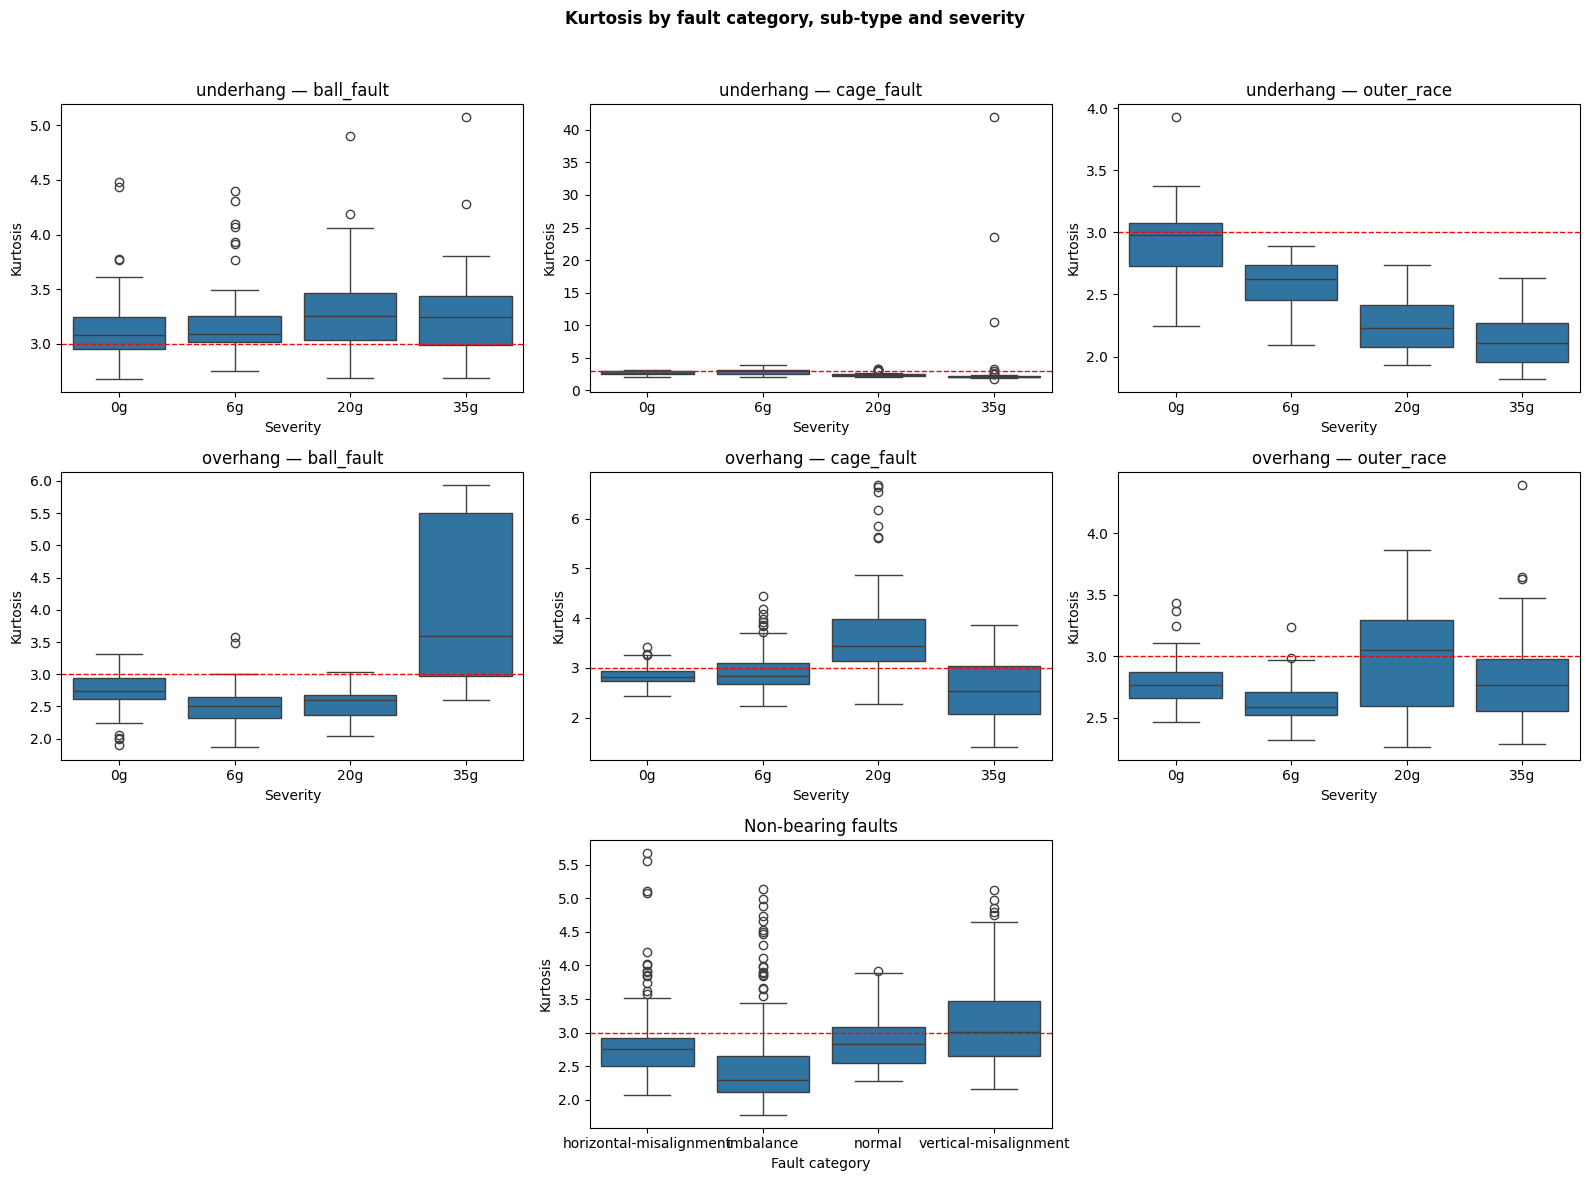

In [ ]:
from scipy import stats
from joblib import Parallel, delayed

# Step 1 — compute kurtosis using the correct channel per fault position
def compute_features_single(row):
    channel = "overhang_radial" if row["fault_category"] == "overhang" else "underhang_radial"
    col_index = CHANNEL_NAMES.index(channel)
    signal = pd.read_csv(row["file_path"], header=None, usecols=[col_index])
    x = signal.iloc[:, 0].values
    return {
        "fault_category": row["fault_category"],
        "sub_type":       row["sub_type"],
        "severity":       row["severity"],
        "rotation_hz":    row["rotation_hz"],
        "kurtosis":       float(stats.kurtosis(x, fisher=False)),
        "rms":            float(np.sqrt(np.mean(x**2))), 
    }

results = Parallel(n_jobs=-1)(
    delayed(compute_features_single)(row)
    for row in df_metadata.to_dict("records")
)
features_df = pd.DataFrame(results)

# Step 2 — plot: 2x3 grid for bearing faults, one extra row for non-bearing
fig, axes = plt.subplots(3, 3, figsize=(16, 12))

positions  = ["underhang", "overhang"]
sub_types  = ["ball_fault", "cage_fault", "outer_race"]
sev_order  = ["0g", "6g", "20g", "35g"]

for row_idx, position in enumerate(positions):
    for col_idx, sub_type in enumerate(sub_types):
        ax = axes[row_idx, col_idx]
        data = features_df[
            (features_df["fault_category"] == position) &
            (features_df["sub_type"] == sub_type)
        ]
        sns.boxplot(data=data, x="severity", y="kurtosis", order=sev_order, ax=ax)
        ax.axhline(3, color="red", linestyle="--", linewidth=1)
        ax.set_title(f"{position} — {sub_type}")
        ax.set_xlabel("Severity")
        ax.set_ylabel("Kurtosis")

# Bottom row — non-bearing categories
non_bearing = features_df[~features_df["fault_category"].isin(["underhang", "overhang"])]
sns.boxplot(data=non_bearing, x="fault_category", y="kurtosis", ax=axes[2, 1])
axes[2, 1].axhline(3, color="red", linestyle="--", linewidth=1)
axes[2, 1].set_title("Non-bearing faults")
axes[2, 1].set_xlabel("Fault category")
axes[2, 1].set_ylabel("Kurtosis")

# Hide unused subplots in the bottom row
axes[2, 0].set_visible(False)
axes[2, 2].set_visible(False)

fig_3.suptitle("Kurtosis by fault category, sub-type and severity", fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

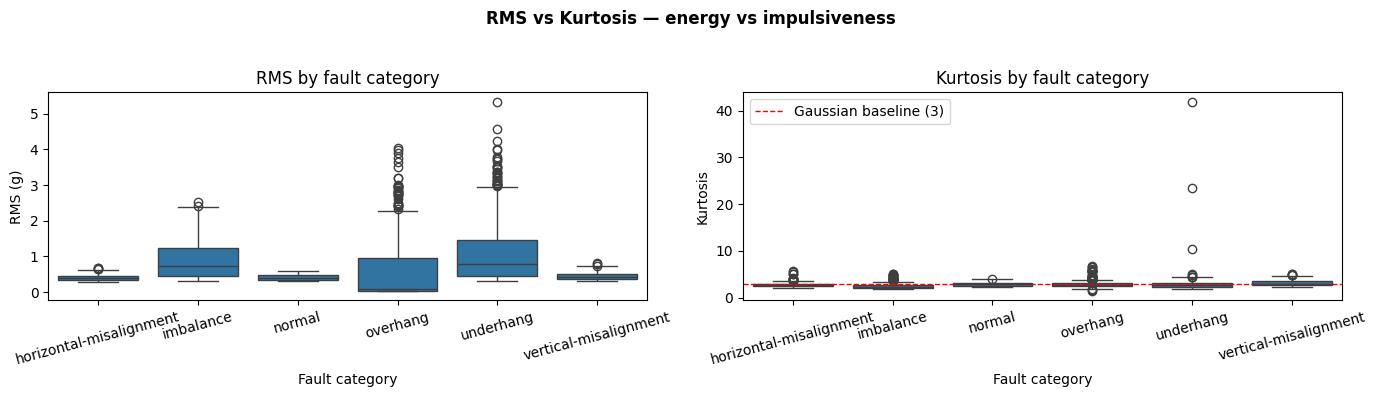

In [55]:
fig_aux, axes_aux = plt.subplots(1, 2, figsize=(14, 4))

# RMS by fault category
sns.boxplot(data=features_df, x="fault_category", y="rms", ax=axes_aux[0])
axes_aux[0].set_title("RMS by fault category")
axes_aux[0].set_xlabel("Fault category")
axes_aux[0].set_ylabel("RMS (g)")
axes_aux[0].tick_params(axis="x", rotation=15)

# Kurtosis by fault category
sns.boxplot(data=features_df, x="fault_category", y="kurtosis", ax=axes_aux[1])
axes_aux[1].axhline(3, color="red", linestyle="--", linewidth=1, label="Gaussian baseline (3)")
axes_aux[1].set_title("Kurtosis by fault category")
axes_aux[1].set_xlabel("Fault category")
axes_aux[1].set_ylabel("Kurtosis")
axes_aux[1].tick_params(axis="x", rotation=15)
axes_aux[1].legend()

fig_aux.suptitle("RMS vs Kurtosis — energy vs impulsiveness", fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Plot 3 — Scatter plot of kurtosis vs. crest factor, colored by fault category
Crest factor (peak / RMS) is related to kurtosis — both measure impulsiveness — but they capture slightly different things. Plotting them together in a 2D scatter with fault category as color shows whether the classes are linearly separable with just two features. If bearing faults cluster away from everything else, that's a strong result. If they overlap, that motivates the need for more features or frequency-domain analysis.

5+6

In [56]:
5+6

11

In [ ]:
fig_3, axes_3 = plt.subplots(3, 3, figsize=(16, 12))

positions = ["underhang", "overhang"]
sub_types = ["ball_fault", "cage_fault", "outer_race"]
sev_order = ["0g", "6g", "20g", "35g"]

for row_idx, position in enumerate(positions):
    for col_idx, sub_type in enumerate(sub_types):
        ax = axes_3[row_idx, col_idx]
        data = features_df[
            (features_df["fault_category"] == position) &
            (features_df["sub_type"] == sub_type)
        ]
        sns.boxplot(data=data, x="severity", y="rms", order=sev_order, ax=ax)
        ax.set_title(f"{position} — {sub_type}")
        ax.set_xlabel("Severity")
        ax.set_ylabel("RMS (g)")

# Bottom row — non-bearing categories
non_bearing = features_df[~features_df["fault_category"].isin(["underhang", "overhang"])]
sns.boxplot(data=non_bearing, x="fault_category", y="rms", ax=axes_3[2, 1])
axes_3[2, 1].set_title("Non-bearing faults")
axes_3[2, 1].set_xlabel("Fault category")
axes_3[2, 1].set_ylabel("RMS (g)")

axes_3[2, 0].set_visible(False)
axes_3[2, 2].set_visible(False)

fig_3.suptitle("RMS by fault category, sub-type and severity", fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()